In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import shap

In [3]:
#Data Specs
data = pd.read_csv("../../data/marketdata.csv")
print(len(data))

minority_class = (data['market_crisis']>0).sum()
majority_class = (data['market_crisis']==0).sum()
imbalance = minority_class/len(data)
print(minority_class)
print(majority_class)
print(imbalance)
print(data.columns.tolist())


4701
434
4267
0.09232078281216763
['Date', 'Vix', 'VIX_roll_10', 'VIX_roll_20', 'VIX_day_change', 'VIX_sd', 'SPY_roll_10', 'SPY_roll_20', 'SPY_roll_60', 'SPY_day_return', 'SPY_5_day_return', 'SPY_20_day_return', 'QQQ_day_return', 'IWM_day_return', 'TLT_day_return', 'GLD_day_return', 'SPY_drawdown', 'QQQ_drawdown', 'IWM_drawdown', 'SPY_TLT_corr_20', 'SPY_TLT_corr_60', 'SPY_GLD_corr_20', 'SPY_VIX_corr_20', 'SPY_vol_ratio', 'QQQ_vol_ratio', 'IWM_vol_ratio', 'spy_above_avg', 'market_crisis']


In [4]:
#Train Test Split
X = data[['Vix', 'VIX_roll_10', 'VIX_roll_20', 'VIX_day_change', 'VIX_sd', 'SPY_roll_10', 'SPY_roll_20', 'SPY_roll_60', 'SPY_day_return', 'SPY_5_day_return', 'SPY_20_day_return', 'QQQ_day_return', 'IWM_day_return', 'TLT_day_return', 'GLD_day_return', 'SPY_drawdown', 'QQQ_drawdown', 'IWM_drawdown', 'SPY_TLT_corr_20', 'SPY_TLT_corr_60', 'SPY_GLD_corr_20', 'SPY_VIX_corr_20', 'SPY_vol_ratio', 'QQQ_vol_ratio', 'IWM_vol_ratio', 'spy_above_avg']]
y = data['market_crisis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

print(len(X_train), len(X_test))

3760 941


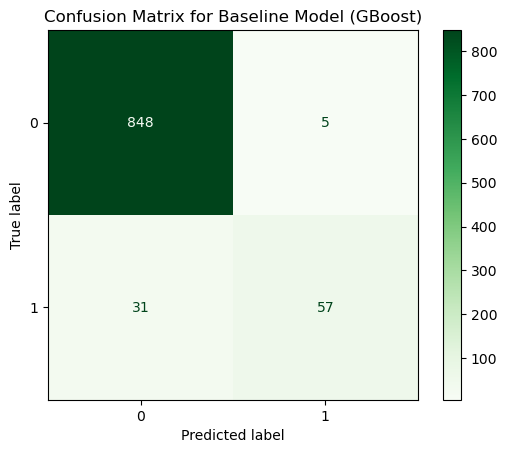

Train Acc:0.9853723404255319
Test Acc:0.9617428267800212
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       853
           1       0.92      0.65      0.76        88

    accuracy                           0.96       941
   macro avg       0.94      0.82      0.87       941
weighted avg       0.96      0.96      0.96       941



In [5]:
#Baseline Model

baseline = GradientBoostingClassifier(random_state=101)
baseline.fit(X_train, y_train)

train_acc = baseline.score(X_train, y_train)
test_acc = baseline.score(X_test, y_test)
base_pred = baseline.predict(X_test)

confusion = confusion_matrix(y_test, base_pred)
conf_plot = ConfusionMatrixDisplay(confusion_matrix=confusion)
conf_plot.plot(cmap="Greens")
plt.title("Confusion Matrix for Baseline Model (GBoost)")
plt.savefig("../visualizations/GB_ML/baseline_matrix_RF.png")
plt.show()

print(f"Train Acc:{train_acc}")
print(f"Test Acc:{test_acc}")
print(classification_report(y_test, base_pred))

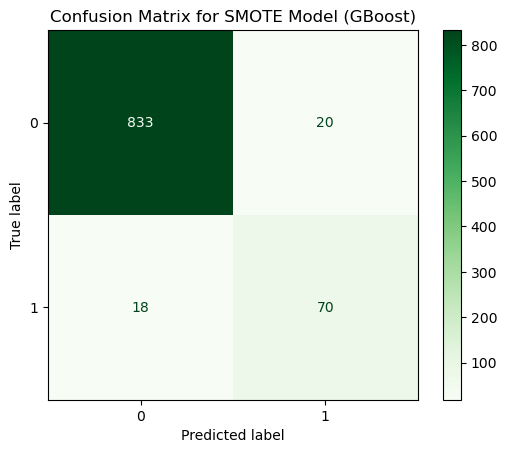

Train Acc:0.9676332747510252
Test Acc:0.9596174282678002
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       853
           1       0.78      0.80      0.79        88

    accuracy                           0.96       941
   macro avg       0.88      0.89      0.88       941
weighted avg       0.96      0.96      0.96       941



In [6]:
#SMOTE model

X_sm_gb, y_sm_gb = SMOTE(random_state=101).fit_resample(X_train, y_train)
gb_smote = GradientBoostingClassifier(random_state=101)
gb_smote.fit(X_sm_gb, y_sm_gb)

sm_train_acc = gb_smote.score(X_sm_gb, y_sm_gb)
sm_test_acc = gb_smote.score(X_test, y_test)
gb_smote_pred = gb_smote.predict(X_test)

confusion = confusion_matrix(y_test, gb_smote_pred)
conf_plot = ConfusionMatrixDisplay(confusion_matrix=confusion)
conf_plot.plot(cmap="Greens")
plt.title("Confusion Matrix for SMOTE Model (GBoost)")
plt.savefig("../visualizations/GB_ML/SMOTE_matrix_RF.png")
plt.show()

print(f"Train Acc:{sm_train_acc}")
print(f"Test Acc:{sm_test_acc}")
print(classification_report(y_test, gb_smote_pred))

In [7]:
#Grid Search for SMOTE GB Model

pipeline = Pipeline([
    ('smote', SMOTE(random_state=101)),
    ('gb', GradientBoostingClassifier(random_state=101))
])

param_grid = {
    'gb__n_estimators': [100, 200],
    'gb__max_depth': [3, 5, 10],
    'gb__learning_rate': [0.01, 0.1, 0.2],
    'gb__min_samples_leaf': [3, 5]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)
print(f"Best params: {grid.best_params_}")
print(f"Best F1: {grid.best_score_}")

Best params: {'gb__learning_rate': 0.1, 'gb__max_depth': 10, 'gb__min_samples_leaf': 5, 'gb__n_estimators': 200}
Best F1: 0.844208696584521


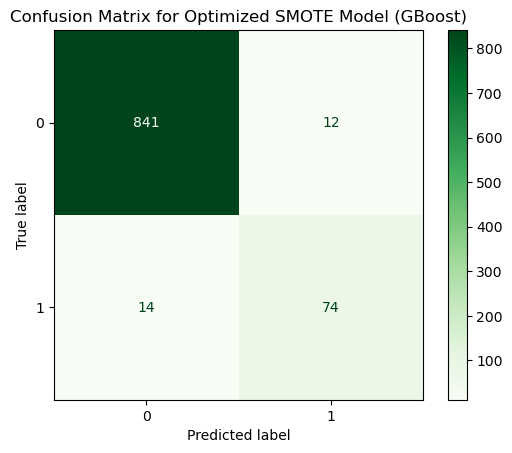

Train Acc:0.9875512595196251
Test Acc:0.9723698193411264
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       853
           1       0.86      0.84      0.85        88

    accuracy                           0.97       941
   macro avg       0.92      0.91      0.92       941
weighted avg       0.97      0.97      0.97       941



In [ ]:
#Best GB Model
best_gb = GradientBoostingClassifier(learning_rate=0.1, max_depth=10, min_samples_leaf=5, n_estimators=200, random_state=101)
best_gb.fit(X_sm_gb, y_sm_gb)

best_train = best_gb.score(X_sm_gb, y_sm_gb)
best_test = best_gb.score(X_test, y_test)
best_gb_pred = best_gb.predict(X_test)

confusion = confusion_matrix(y_test, best_gb_pred)
conf_plot = ConfusionMatrixDisplay(confusion_matrix=confusion)
conf_plot.plot(cmap="Greens")
plt.title("Confusion Matrix for Optimized SMOTE Model (GBoost)")
plt.savefig("../visualizations/GB_ML/op_SMOTE_matrix_RF.png")
plt.show()

print(f"Train Acc:{best_train}")
print(f"Test Acc:{best_test}")
print(classification_report(y_test, best_gb_pred))

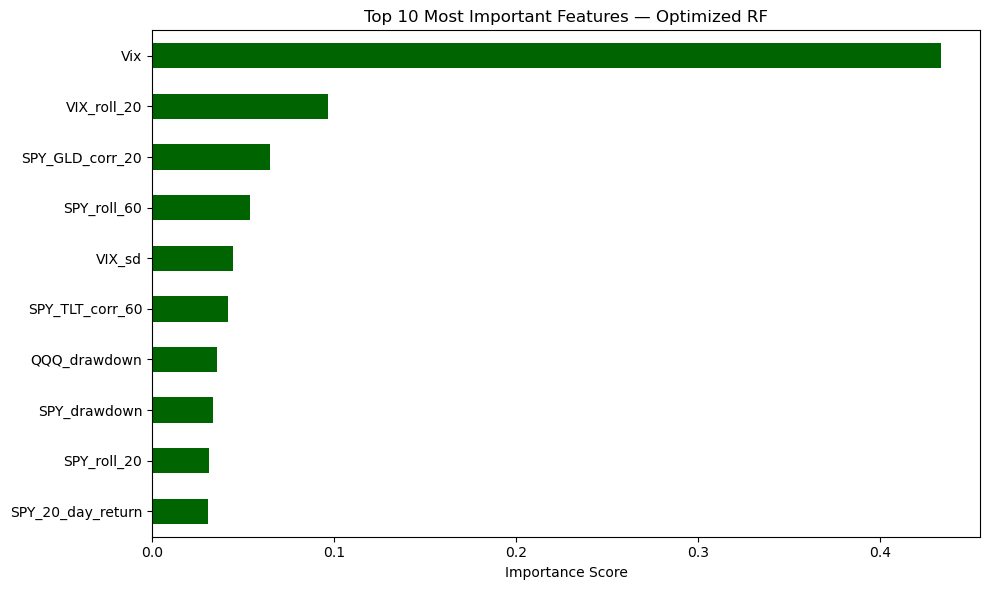

In [9]:
importances = pd.Series(
    best_gb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_10 = importances.head(10)

plt.figure(figsize=(10, 6))
top_10.plot(kind='barh', color='darkgreen')
plt.title("Top 10 Most Important Features — Optimized RF")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../visualizations/GB_ML/feature_importance_top10_GB.png")
plt.show()

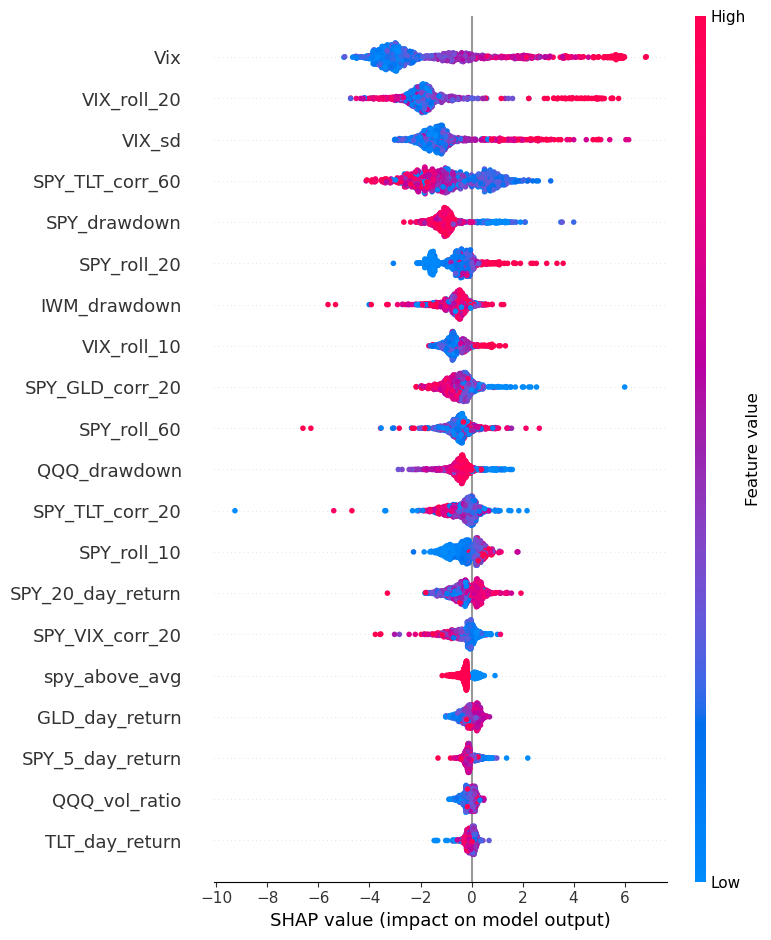

In [10]:
explainer = shap.TreeExplainer(best_gb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=X_train.columns, show=False)
plt.savefig("../visualizations/GB_ML/GB_SHAP.png")
plt.show()


In [ ]:
import pickle
import os

os.makedirs("best_mod", exist_ok=True)

with open("best_mod/best_model.pkl", "rb") as f:
    test_model = pickle.load(f)

print(type(test_model))
print(hasattr(test_model, 'predict_proba'))
print(best_gb.feature_names_in_)

<class 'sklearn.ensemble._gb.GradientBoostingClassifier'>
True
['Vix' 'VIX_roll_10' 'VIX_roll_20' 'VIX_day_change' 'VIX_sd' 'SPY_roll_10'
 'SPY_roll_20' 'SPY_roll_60' 'SPY_day_return' 'SPY_5_day_return'
 'SPY_20_day_return' 'QQQ_day_return' 'IWM_day_return' 'TLT_day_return'
 'GLD_day_return' 'SPY_drawdown' 'QQQ_drawdown' 'IWM_drawdown'
 'SPY_TLT_corr_20' 'SPY_TLT_corr_60' 'SPY_GLD_corr_20' 'SPY_VIX_corr_20'
 'SPY_vol_ratio' 'QQQ_vol_ratio' 'IWM_vol_ratio' 'spy_above_avg']
